In [ ]:
# 2.2 使用 NumPy 完成矩阵运算
import numpy as np

# 1. 3x4 标准正态随机矩阵 X
np.random.seed(42)
X = np.random.randn(3, 4)
print("X:\n", X)

# 2. 4x2 全1矩阵 Y
Y = np.ones((4, 2))
print("\nY:\n", Y)

# 3. 矩阵乘法 Z = X @ Y
Z = X @ Y
print("\nZ:\n", Z)

# 4. 输出 Z 的第一行第二列元素，以及第二行所有元素
print("\nZ[0,1] (第一行第二列):", Z[0, 1])
print("Z 的第二行:", Z[1, :])

# 5. Z 的 Frobenius 范数
fro_norm = np.linalg.norm(Z, 'fro')
print("\nZ 的 Frobenius 范数:", fro_norm)

X:
 [[ 0.49671415 -0.1382643   0.64768854  1.52302986]
 [-0.23415337 -0.23413696  1.57921282  0.76743473]
 [-0.46947439  0.54256004 -0.46341769 -0.46572975]]

Y:
 [[1. 1.]
 [1. 1.]
 [1. 1.]
 [1. 1.]]

Z:
 [[ 2.52916825  2.52916825]
 [ 1.87835721  1.87835721]
 [-0.85606179 -0.85606179]]

Z[0,1] (第一行第二列): 2.5291682463487657
Z 的第二行: [1.87835721 1.87835721]

Z 的 Frobenius 范数: 4.616873319476863


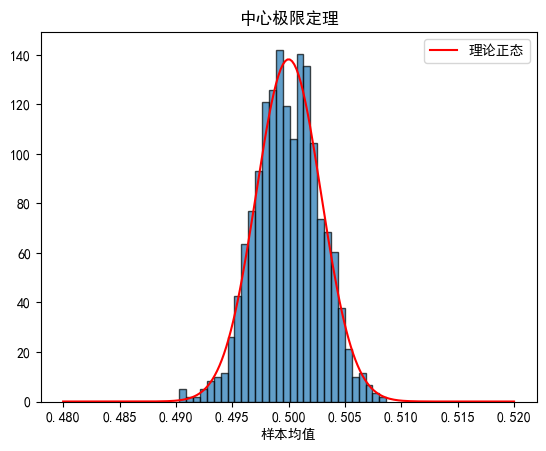

实际方差: 8.099054042393729e-06
理论方差: 8.333333333333334e-06


In [4]:
# 3.2 模拟中心极限定理
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

n = 10000   # 每个样本的随机变量个数
m = 1000    # 重复次数

means = [np.mean(np.random.uniform(0, 1, n)) for _ in range(m)]

plt.hist(means, bins=30, density=True, alpha=0.7, edgecolor='black')
x = np.linspace(0.48, 0.52, 200)
plt.plot(x, norm.pdf(x, 0.5, np.sqrt(1/(12*n))), 'r-', label='理论正态')
plt.title('中心极限定理')
plt.xlabel('样本均值')
plt.legend()
plt.show()

actual_var = np.var(means)
print("实际方差:", actual_var)
print("理论方差:", 1/(12*n))

In [7]:
# 4.2 手动反向传播 vs torch.autograd
import torch

x, w1, w2 = 2.0, 1.5, 0.5

# 前向
a = x * w1
b = a + w2
L = b ** 2
print("前向结果 L =", L)

# 手动梯度
grad_w1_manual = 2 * b * x
grad_w2_manual = 2 * b
print(f"手动梯度: dL/dw1 = {grad_w1_manual}, dL/dw2 = {grad_w2_manual}")

# 自动微分验证
w1_t = torch.tensor(w1, requires_grad=True)
w2_t = torch.tensor(w2, requires_grad=True)
x_t = torch.tensor(x)
L_t = (x_t * w1_t + w2_t) ** 2
L_t.backward()
print(f"自动微分: dL/dw1 = {w1_t.grad.item()}, dL/dw2 = {w2_t.grad.item()}")

前向结果 L = 12.25
手动梯度: dL/dw1 = 14.0, dL/dw2 = 7.0
自动微分: dL/dw1 = 14.0, dL/dw2 = 7.0


In [8]:
# 5.2 从零实现 softmax 回归
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 数据加载与预处理
digits = load_digits()
X = digits.images.reshape(len(digits.images), -1)
y = digits.target.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)
y_test_onehot = encoder.transform(y_test)

# 初始化参数
input_dim, num_classes = 64, 10
W = np.random.randn(input_dim, num_classes) * 0.01
b = np.zeros((1, num_classes))

# Softmax 与交叉熵
def softmax(logits):
    exp_logits = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

def cross_entropy(y_pred, y_true):
    return -np.mean(y_true * np.log(y_pred + 1e-8))

# 训练参数
batch_size, lr, epochs = 32, 0.1, 50

for epoch in range(epochs):
    indices = np.random.permutation(len(X_train))
    for i in range(0, len(X_train), batch_size):
        batch_idx = indices[i:i+batch_size]
        X_batch = X_train[batch_idx]
        y_batch = y_train_onehot[batch_idx]

        logits = X_batch @ W + b
        y_pred = softmax(logits)
        loss = cross_entropy(y_pred, y_batch)

        grad_logits = y_pred - y_batch
        grad_W = X_batch.T @ grad_logits / batch_size
        grad_b = np.mean(grad_logits, axis=0, keepdims=True)

        W -= lr * grad_W
        b -= lr * grad_b

    # 测试准确率
    logits_test = X_test @ W + b
    y_pred_test = softmax(logits_test)
    acc = np.mean(np.argmax(y_pred_test, axis=1) == np.argmax(y_test_onehot, axis=1))
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Test Acc: {acc:.4f}")

print(f"\n最终测试集准确率: {acc:.4f}")

Epoch  10 | Test Acc: 0.9500
Epoch  20 | Test Acc: 0.9528
Epoch  30 | Test Acc: 0.9583
Epoch  40 | Test Acc: 0.9639
Epoch  50 | Test Acc: 0.9667

最终测试集准确率: 0.9667


测试集准确率: 0.0500


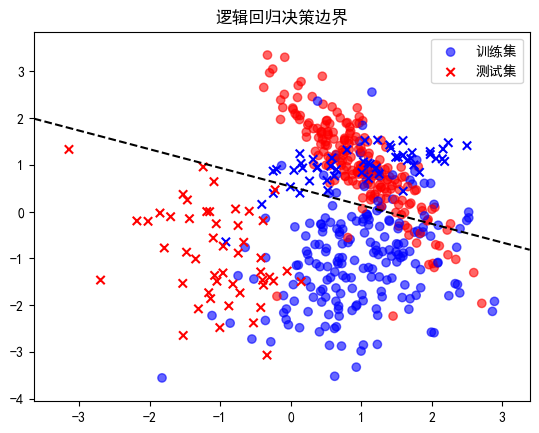

In [3]:
# 6.2 逻辑回归（不使用高级API）
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# 设置中文字体（支持Windows/Mac/Linux常见中文字体）
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 训练集：400个样本（每类200个），线性可分
X_train, y_train = make_classification(n_samples=400, n_features=2, n_redundant=0,
                                        n_clusters_per_class=1, flip_y=0.05, random_state=42)
y_train = y_train.reshape(-1, 1)

# 测试集：独立新生成100个样本（每类50个），同样线性可分
X_test, y_test = make_classification(n_samples=100, n_features=2, n_redundant=0,
                                      n_clusters_per_class=1, flip_y=0.05, random_state=123)
y_test = y_test.reshape(-1, 1)

# Sigmoid 与损失
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def bce_loss(y_pred, y_true):
    eps = 1e-8
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

# 梯度下降
w, b = np.zeros((2, 1)), 0.0
lr, n_iter = 0.1, 1000

for _ in range(n_iter):
    logits = X_train @ w + b
    y_pred = sigmoid(logits)
    grad_w = X_train.T @ (y_pred - y_train) / len(X_train)
    grad_b = np.mean(y_pred - y_train)
    w -= lr * grad_w
    b -= lr * grad_b

# 测试准确率
y_test_pred = (sigmoid(X_test @ w + b) >= 0.5).astype(int)
acc = np.mean(y_test_pred == y_test)
print(f"测试集准确率: {acc:.4f}")

# 绘制决策边界（使用全部数据确定坐标范围）
all_X = np.vstack([X_train, X_test])
plt.scatter(X_train[:,0], X_train[:,1], c=y_train.ravel(), cmap='bwr', alpha=0.6, label='训练集')
plt.scatter(X_test[:,0], X_test[:,1], c=y_test.ravel(), cmap='bwr', marker='x', label='测试集')
x_min, x_max = all_X[:,0].min()-0.5, all_X[:,0].max()+0.5
y_min, y_max = all_X[:,1].min()-0.5, all_X[:,1].max()+0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200), np.linspace(y_min, y_max, 200))
Z = sigmoid(np.c_[xx.ravel(), yy.ravel()] @ w + b).reshape(xx.shape)
plt.contour(xx, yy, Z, levels=[0.5], colors='black', linestyles='--')
plt.title('逻辑回归决策边界')
plt.legend()
plt.show()